In [5]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("mathchi/churn-for-bank-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-for-bank-customers' dataset.
Path to dataset files: /kaggle/input/churn-for-bank-customers


In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/churn-for-bank-customers/.nfs0000000047c523db000001e2
/kaggle/input/churn-for-bank-customers/churn.csv


In [7]:
df=pd.read_csv("/kaggle/input/churn-for-bank-customers/churn.csv")

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape

(10000, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [13]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [14]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [15]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


In [16]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [17]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [18]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [19]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [20]:
df.shape

(10000, 12)

In [21]:
X=df.drop("Exited",axis=1)
y=df["Exited"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [23]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [24]:
X_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [26]:
model=Sequential()
model.add(Dense(11,activation="relu",input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer="adam",
    metrics=["accuracy"],
    loss="binary_crossentropy"
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(
    X_train,
    y_train,
    batch_size=50,
    epochs=30,
    verbose=1,
    validation_split=0.2,

)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7119 - loss: 0.6008 - val_accuracy: 0.7975 - val_loss: 0.5178
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7933 - loss: 0.4977 - val_accuracy: 0.7987 - val_loss: 0.4753
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.4697 - val_accuracy: 0.7987 - val_loss: 0.4534
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7939 - loss: 0.4500 - val_accuracy: 0.8012 - val_loss: 0.4373
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7998 - loss: 0.4349 - val_accuracy: 0.8037 - val_loss: 0.4256
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8008 - loss: 0.4244 - val_accuracy: 0.8106 - val_loss: 0.4182
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8056 - loss: 0.4172 - val_accuracy: 0.8181 - val_loss: 0.4125
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8109 - loss: 0.4112 - val_accuracy: 0.

In [29]:
history=model.fit(
    X_train,
    y_train,
    batch_size=50,
    epochs=30,
    verbose=1,
    validation_split=0.2,

)
history.history

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8608 - loss: 0.3376 - val_accuracy: 0.8562 - val_loss: 0.3498
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8605 - loss: 0.3375 - val_accuracy: 0.8562 - val_loss: 0.3496
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8627 - loss: 0.3371 - val_accuracy: 0.8544 - val_loss: 0.3491
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8616 - loss: 0.3367 - val_accuracy: 0.8556 - val_loss: 0.3482
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8611 - loss: 0.3357 - val_accuracy: 0.8569 - val_loss: 0.3492
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8634 - loss: 0.3363 - val_accuracy: 0.8550 - val_loss: 0.3483
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8633 - loss: 0.3353 - val_accuracy: 0.8519 - val_loss: 0.3485
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8611 - loss: 0.3356 - val_accuracy: 0.

{'accuracy': [0.8607812523841858,
  0.8604687452316284,
  0.8626562356948853,
  0.8615624904632568,
  0.8610937595367432,
  0.8634374737739563,
  0.86328125,
  0.8610937595367432,
  0.8618749976158142,
  0.8635937571525574,
  0.8628125190734863,
  0.8639062643051147,
  0.8631250262260437,
  0.8642187714576721,
  0.8653125166893005,
  0.8645312786102295,
  0.8631250262260437,
  0.8639062643051147,
  0.8643749952316284,
  0.86328125,
  0.86328125,
  0.864062488079071,
  0.8650000095367432,
  0.8646875023841858,
  0.8646875023841858,
  0.8660937547683716,
  0.8660937547683716,
  0.8648437261581421,
  0.8651562333106995,
  0.8651562333106995],
 'loss': [0.3375779390335083,
  0.3375469446182251,
  0.3370632827281952,
  0.3367187976837158,
  0.33568698167800903,
  0.3362838327884674,
  0.33527252078056335,
  0.33557024598121643,
  0.3352142572402954,
  0.3345816433429718,
  0.3346496820449829,
  0.33435890078544617,
  0.3339669704437256,
  0.3341345191001892,
  0.33359354734420776,
  0.33373

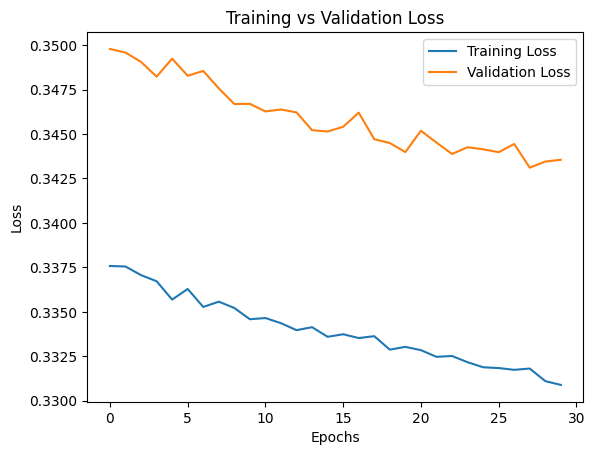

In [30]:
import matplotlib.pyplot as plt

# Training loss
loss = history.history['loss']

# Validation loss
val_loss = history.history['val_loss']

# Plot
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

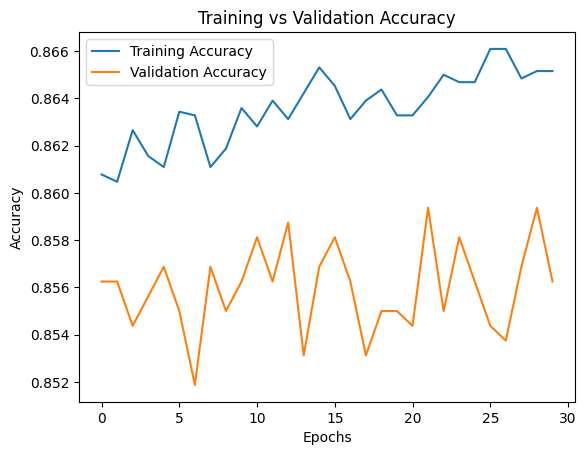

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [32]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8530 - loss: 0.3419
Test Loss: 0.3419170081615448
Test Accuracy: 0.8529999852180481


In [33]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [34]:
y_pred = (y_pred > 0.3)

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1426  181]
 [ 143  250]]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1607
           1       0.58      0.64      0.61       393

    accuracy                           0.84      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.84      0.84      2000



# Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
)

In [38]:
df=pd.read_csv("/kaggle/input/churn-for-bank-customers/churn.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63     


Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


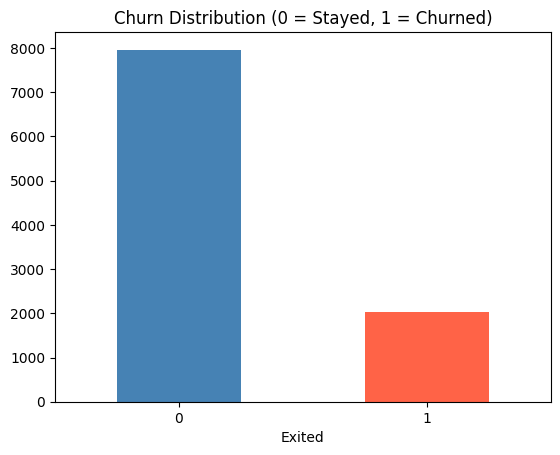

In [39]:
print("\nChurn distribution:")
print(df["Exited"].value_counts())

# Visualize churn rate
df["Exited"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.xticks(rotation=0)
plt.savefig("churn_distribution.png", bbox_inches="tight")
plt.show()

In [40]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df["Geography"] = le.fit_transform(df["Geography"])   # France/Germany/Spain → 0/1/2
df["Gender"]    = le.fit_transform(df["Gender"])       # Female/Male → 0/1

print("\nFeatures after encoding:")
print(df.dtypes)


Features after encoding:
CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [41]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (8000, 10), Test size: (2000, 10)


In [42]:
rf = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=10,           # prevent overfitting
    class_weight="balanced", # handles imbalanced churn data
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf.fit(X_train, y_train)
print("\nModel trained!")


Model trained!


In [43]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.4f}")


── Classification Report ──
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.61      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000

F1 Score  : 0.6322
AUC-ROC   : 0.8547


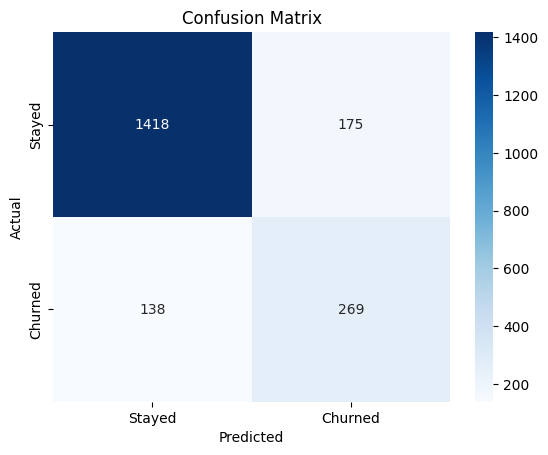

In [44]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

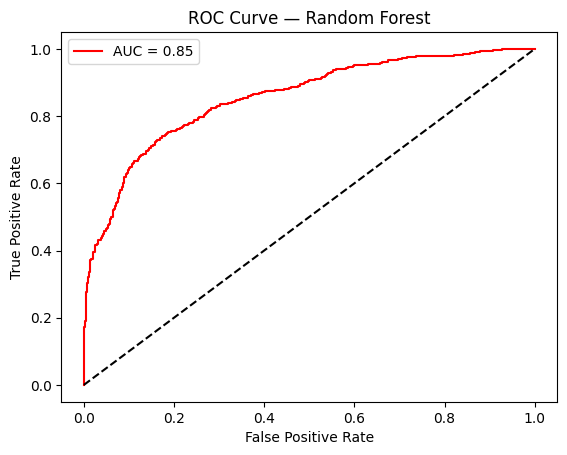

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color="red", label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()

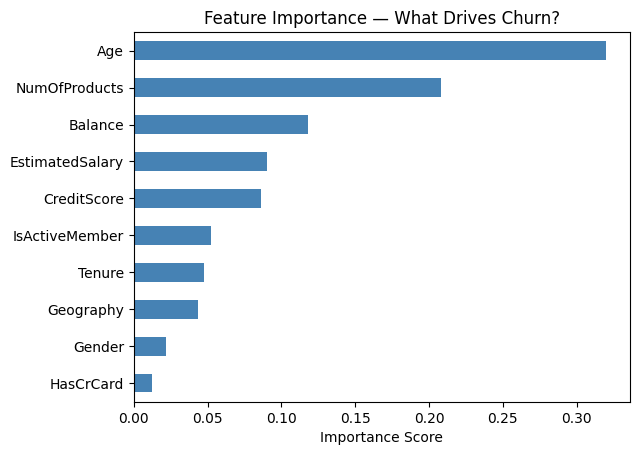


Top 3 churn drivers:
Age              0.320085
NumOfProducts    0.207875
Balance          0.117682
dtype: float64


In [46]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance — What Drives Churn?")
plt.xlabel("Importance Score")
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 3 churn drivers:")
print(importances.sort_values(ascending=False).head(3))

# XG boost
in this we will be  using XG boost and compare it to other things we have used previously

In [47]:
from xgboost import XGBClassifier

In [48]:
df = pd.read_csv("/kaggle/input/churn-for-bank-customers/churn.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63     


Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


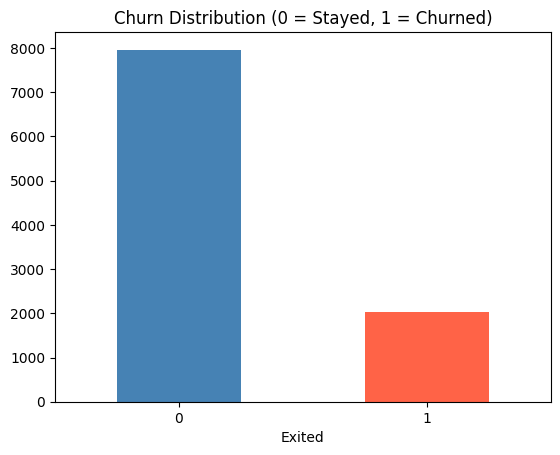

In [49]:
print("\nChurn distribution:")
print(df["Exited"].value_counts())

df["Exited"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.xticks(rotation=0)
plt.savefig("churn_distribution.png", bbox_inches="tight")
plt.show()

In [50]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

le = LabelEncoder()
df["Geography"] = le.fit_transform(df["Geography"])
df["Gender"]    = le.fit_transform(df["Gender"])

In [51]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (8000, 10), Test size: (2000, 10)


In [52]:
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}  (handles imbalance)")


scale_pos_weight: 3.91  (handles imbalance)


In [53]:
xgb = XGBClassifier(
    n_estimators=200,           # more trees than RF — XGBoost builds them sequentially
    max_depth=6,                # shallower trees work better in boosting
    learning_rate=0.05,         # slow learning = better generalization
    subsample=0.8,              # use 80% of rows per tree (prevents overfitting)
    colsample_bytree=0.8,       # use 80% of features per tree
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50                  # print progress every 50 rounds
)
print("\nModel trained!")

[0]	validation_0-logloss:0.68216


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:08:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.45217
[100]	validation_0-logloss:0.42599
[150]	validation_0-logloss:0.41529
[199]	validation_0-logloss:0.40721

Model trained!


In [54]:
y_pred  = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.4f}")


── Classification Report ──
              precision    recall  f1-score   support

      Stayed       0.92      0.84      0.88      1593
     Churned       0.53      0.71      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.82      2000

F1 Score  : 0.6120
AUC-ROC   : 0.8562


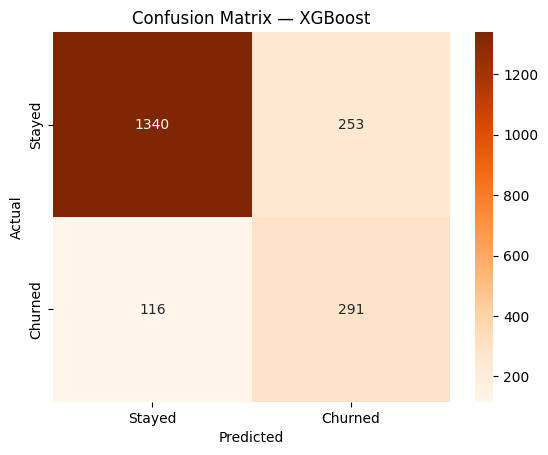

In [55]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"])
plt.title("Confusion Matrix — XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

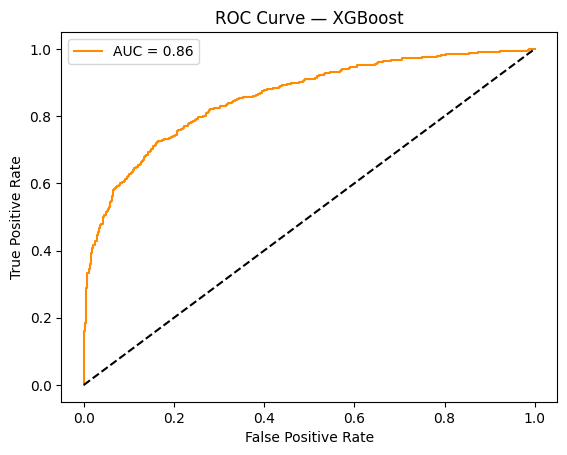

In [56]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()

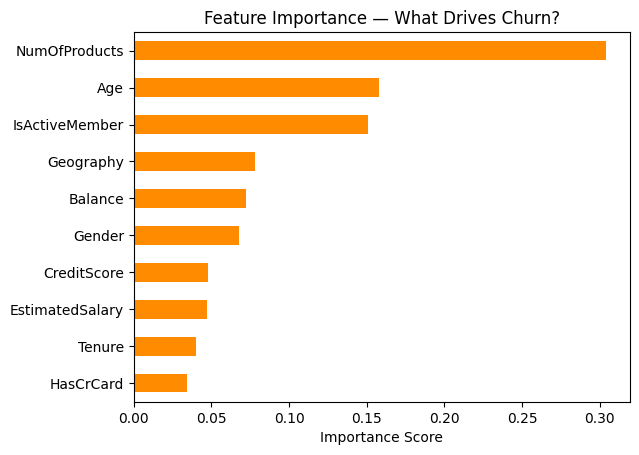


Top 3 churn drivers:
NumOfProducts     0.304175
Age               0.157887
IsActiveMember    0.150951
dtype: float32


In [57]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", color="darkorange")
plt.title("Feature Importance — What Drives Churn?")
plt.xlabel("Importance Score")
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 3 churn drivers:")
print(importances.sort_values(ascending=False).head(3))

## Model Comparison: Random Forest vs. XGBoost

In [59]:
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'F1 Score': [0.6322, 0.6120],
    'AUC-ROC': [0.8547, 0.8562]
})
display(model_comparison)

,Model,F1 Score,AUC-ROC
0,Random Forest,0.6322,0.8547
1,XGBoost,0.6120,0.8562


Based on these metrics, the Random Forest model shows a slightly higher F1 Score, while the XGBoost model has a marginally better AUC-ROC score. Both models perform similarly in this context.